# Baseline: TF-IDF + Logistic Regression for Kwaai/IMDB_Sentiment.

In [1]:
from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import re
import pandas as pd

class CustomLogisticRegression:
    def __init__(
        self,
        learning_rate=5.0,
        epochs=500,
        lambda_reg=0.0,
        patience=10,
        min_delta=1e-4
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.lambda_reg = lambda_reg
        self.patience = patience
        self.min_delta = min_delta

        self.weights = None
        self.bias = 0.0
        self.loss_history = []
        self.val_loss_history = []
        self.best_epoch = None

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y_true, y_prob):
        epsilon = 1e-15
        y_prob = np.clip(y_prob, epsilon, 1 - epsilon)


        bce_loss = -np.mean(
            y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob)
        )


        l2_loss = self.lambda_reg / 2 * np.sum(self.weights ** 2)

        return bce_loss + l2_loss

    def fit(self, X, y, X_val=None, y_val=None, verbose=False):
        n_samples, n_features = X.shape
    
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []
        self.val_loss_history = []
    
        best_val_loss = np.inf
        best_weights = None
        best_bias = None
        patience_counter = 0
    
        for epoch in range(self.epochs):
    

            linear_output = X @ self.weights + self.bias
            y_prob = self.sigmoid(linear_output)
    

            loss = self.compute_loss(y, y_prob)
            self.loss_history.append(loss)
    

            error = y_prob - y
            dw = np.asarray(X.T @ error).ravel() / n_samples
            dw += self.lambda_reg * self.weights
            db = np.mean(error)
    

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
    

            if X_val is not None and y_val is not None:
                val_prob = self.predict_proba(X_val)
                val_loss = self.compute_loss(y_val, val_prob)
                self.val_loss_history.append(val_loss)
    

                if val_loss < best_val_loss - self.min_delta:
                    best_val_loss = val_loss
                    best_weights = self.weights.copy()
                    best_bias = self.bias
                    self.best_epoch = epoch + 1
                    patience_counter = 0
                else:
                    patience_counter += 1
    
                if patience_counter >= self.patience:
                    if verbose:
                        print(f"Early stopping at epoch {epoch + 1}")
                        print(f"Best epoch: {self.best_epoch}")
    
                    self.weights = best_weights
                    self.bias = best_bias
                    break
    
            if verbose and (epoch == 0 or (epoch + 1) % 50 == 0):
                if X_val is not None:
                    print(
                        f"Epoch {epoch + 1:03d}/{self.epochs} "
                        f"- Training Loss: {loss:.6f} "
                        f"- Validation Loss: {val_loss:.6f}"
                    )
                else:
                    print(
                        f"Epoch {epoch + 1:03d}/{self.epochs} "
                        f"- Training Loss: {loss:.6f}"
                    )
    
        return self

    def predict_proba(self, X):
        linear_output = X @ self.weights + self.bias
        return self.sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)




### Datasets loading and splitting

In [2]:
def clean_text(text):

    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)

    text = re.sub(r"\s+", " ", text)

    return text.strip()
dataset = load_dataset("Kwaai/IMDB_Sentiment")

train = dataset["train"]
test = dataset["test"]

texts = np.array(train["text"])
labels = np.array(train["label"])

test_texts = np.array(test["text"])
y_test = np.array(test["label"])

# 8:2 Train / Validation Split

train_texts, val_texts, y_train, y_val = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
train_texts = [clean_text(text) for text in train_texts]
val_texts = [clean_text(text) for text in val_texts]
test_texts = [clean_text(text) for text in test_texts]



print("Generating TF-IDF features...")

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 1),
    max_features=5000
)

X_train = tfidf.fit_transform(train_texts)
X_val = tfidf.transform(val_texts)
X_test = tfidf.transform(test_texts)

print(f"Training Feature Shape   : {X_train.shape}")
print(f"Validation Feature Shape : {X_val.shape}")
print(f"Test Feature Shape       : {X_test.shape}")

Generating TF-IDF features...
Training Feature Shape   : (20000, 5000)
Validation Feature Shape : (5000, 5000)
Test Feature Shape       : (25000, 5000)


### Hyperparameter Search

In [3]:


learning_rates = [0.5, 1.0, 5.0]
lambda_values = [0.1, 0.01, 0.001]
epochs = 500

experiment_results = []

best_val_accuracy = -1
best_learning_rate = None
best_lambda = None

print("Hyperparameter Search")
print("=" * 70)

for learning_rate in learning_rates:
    for lambda_reg in lambda_values:
        print(
            f"Training with Learning Rate = {learning_rate}, "
            f"Lambda = {lambda_reg}"
        )

        model = CustomLogisticRegression(
            learning_rate=learning_rate,
            epochs=epochs,
            lambda_reg=lambda_reg,
            patience=10,
            min_delta=1e-4
        )

        model.fit(X_train, y_train, X_val=X_val, y_val=y_val, verbose=False)


        val_predictions = model.predict(X_val)


        val_accuracy = accuracy_score(y_val, val_predictions)


        final_loss = model.loss_history[-1]

        experiment_results.append(
            (learning_rate, lambda_reg, final_loss, val_accuracy)
        )

        print(f"Final Training Loss : {final_loss:.6f}")
        print(f"Validation Accuracy : {val_accuracy:.6f}")
        print()

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_learning_rate = learning_rate
            best_lambda = lambda_reg
            best_epoch = model.best_epoch
print("Complete.")

Hyperparameter Search
Training with Learning Rate = 0.5, Lambda = 0.1
Final Training Loss : 0.691020
Validation Accuracy : 0.777400

Training with Learning Rate = 0.5, Lambda = 0.01
Final Training Loss : 0.674286
Validation Accuracy : 0.783600

Training with Learning Rate = 0.5, Lambda = 0.001
Final Training Loss : 0.624774
Validation Accuracy : 0.790600

Training with Learning Rate = 1.0, Lambda = 0.1
Final Training Loss : 0.690967
Validation Accuracy : 0.776000

Training with Learning Rate = 1.0, Lambda = 0.01
Final Training Loss : 0.673822
Validation Accuracy : 0.784400

Training with Learning Rate = 1.0, Lambda = 0.001
Final Training Loss : 0.598735
Validation Accuracy : 0.804600

Training with Learning Rate = 5.0, Lambda = 0.1
Final Training Loss : 0.690962
Validation Accuracy : 0.779600

Training with Learning Rate = 5.0, Lambda = 0.01
Final Training Loss : 0.673333
Validation Accuracy : 0.785800

Training with Learning Rate = 5.0, Lambda = 0.001
Final Training Loss : 0.579378
Va

### Show the best hyperparameter

In [4]:

print("Hyperparameter Comparison")
print("=" * 75)

print(
    f"{'Learning Rate':<18}"
    f"{'Lambda':<15}"
    f"{'Final Loss':<18}"
    f"{'Validation Accuracy':<20}"
)

print("-" * 75)

for learning_rate, lambda_reg, final_loss, val_accuracy in experiment_results:
    print(
        f"{learning_rate:<18}"
        f"{lambda_reg:<15}"
        f"{final_loss:<18.6f}"
        f"{val_accuracy:<20.6f}"
        
    )



print()
print("Best Hyperparameters")
print("=" * 60)

print(f"Learning Rate       : {best_learning_rate}")
print(f"L2 Lambda           : {best_lambda}")
print(f"Validation Accuracy : {best_val_accuracy:.6f}")
print(f"Best Epochs              : {best_epoch}")


Hyperparameter Comparison
Learning Rate     Lambda         Final Loss        Validation Accuracy 
---------------------------------------------------------------------------
0.5               0.1            0.691020          0.777400            
0.5               0.01           0.674286          0.783600            
0.5               0.001          0.624774          0.790600            
1.0               0.1            0.690967          0.776000            
1.0               0.01           0.673822          0.784400            
1.0               0.001          0.598735          0.804600            
5.0               0.1            0.690962          0.779600            
5.0               0.01           0.673333          0.785800            
5.0               0.001          0.579378          0.827600            

Best Hyperparameters
Learning Rate       : 5.0
L2 Lambda           : 0.001
Validation Accuracy : 0.827600
Best Epochs              : 306


### Rebuild TF-IDF & Final model training

Retraining best model using all 25k training samples...

Full Training Feature Shape : (25000, 5000)
Test Feature Shape          : (25000, 5000)
Epoch 001/306 - Training Loss: 0.693147
Epoch 050/306 - Training Loss: 0.626141
Epoch 100/306 - Training Loss: 0.599840
Epoch 150/306 - Training Loss: 0.588819
Epoch 200/306 - Training Loss: 0.583916
Epoch 250/306 - Training Loss: 0.581651
Epoch 300/306 - Training Loss: 0.580577

Final Test Results
Accuracy  : 0.828880
Precision : 0.817158
Recall    : 0.847360
F1 Score  : 0.831985


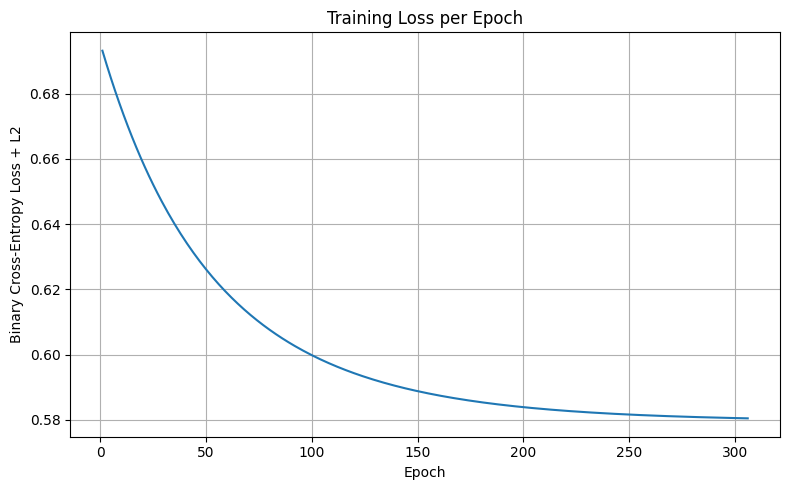

In [5]:
print("Retraining best model using all 25k training samples...\n")



full_train_texts = [
    clean_text(text) for text in train["text"]
]

full_test_texts = [
    clean_text(text) for text in test["text"]
]

y_full_train = np.array(train["label"])
y_test = np.array(test["label"])




tfidf_final = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 1),
    max_features=5000
)

X_full_train = tfidf_final.fit_transform(full_train_texts)
X_test = tfidf_final.transform(full_test_texts)

print(f"Full Training Feature Shape : {X_full_train.shape}")
print(f"Test Feature Shape          : {X_test.shape}")



final_model = CustomLogisticRegression(
    learning_rate=best_learning_rate,
    epochs=best_epoch,
    lambda_reg=best_lambda,
    patience=10,
    min_delta=1e-4
)

final_model.fit(
    X_full_train,
    y_full_train,
    verbose=True
)



predictions = final_model.predict(X_test)


accuracy = accuracy_score(
    y_test,
    predictions
)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    predictions,
    average="binary",
    pos_label=1,
    zero_division=0
)


print()
print("Final Test Results")
print("=" * 40)

print(f"Accuracy  : {accuracy:.6f}")
print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"F1 Score  : {f1:.6f}")

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(final_model.loss_history) + 1),
    final_model.loss_history
)

plt.xlabel("Epoch")

if best_lambda == 0:
    plt.ylabel("Binary Cross-Entropy Loss")
else:
    plt.ylabel("Binary Cross-Entropy Loss + L2")

plt.title("Training Loss per Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
print("=" * 60)
print("TF-IDF & Logistic Regression")

print(f"Training Samples : {len(train)}")
print(f"Testing Samples  : {len(test)}")
print("TF-IDF Features  : 5000")
print("N-gram           : Unigram")
print(f"Learning Rate    : {best_learning_rate}")
print(f"Epochs           : {best_epoch}")
print(f"L2 Lambda        : {best_lambda}")

print("=" * 50)

print(f"{'Metric':<15}{'Value':>12}")
print("-" * 27)

print(f"{'Accuracy':<15}{accuracy:>12.6f}")
print(f"{'Precision':<15}{precision:>12.6f}")
print(f"{'Recall':<15}{recall:>12.6f}")
print(f"{'F1-score':<15}{f1:>12.6f}")

TF-IDF & Logistic Regression
Training Samples : 25000
Testing Samples  : 25000
TF-IDF Features  : 5000
N-gram           : Unigram
Learning Rate    : 5.0
Epochs           : 306
L2 Lambda        : 0.001
Metric                Value
---------------------------
Accuracy           0.828880
Precision          0.817158
Recall             0.847360
F1-score           0.831985


In [7]:
feature_names = tfidf_final.get_feature_names_out()

weights = final_model.weights

feature_importance = list(zip(feature_names, weights))

feature_importance = sorted(
    feature_importance,
    key=lambda x: x[1]
)

top_negative = feature_importance[:10]
top_positive = feature_importance[-10:][::-1]

positive_df = pd.DataFrame(
    top_positive,
    columns=["Positive Feature","Weight"]
)

negative_df = pd.DataFrame(
    top_negative,
    columns=["Negative Feature","Weight"]
)

display(positive_df)
display(negative_df)

,Positive Feature,Weight
0,great,1.887717
1,and,1.542971
2,best,1.130709
3,love,1.097635
4,excellent,1.046565
5,very,0.947808
6,well,0.923995
7,wonderful,0.892957
8,also,0.731728
9,loved,0.719934


,Negative Feature,Weight
0,bad,-2.475984
1,worst,-1.683232
2,no,-1.399248
3,waste,-1.164368
4,awful,-1.153645
5,even,-1.084796
6,nothing,-1.013850
7,boring,-1.005253
8,just,-0.986066
9,terrible,-0.967153
